In [2]:
from google.colab import drive
drive.mount('/content/drive')

# cd to the *root* of career-ml, NOT to scripts
%cd "/content/drive/MyDrive/SLIIT/Research/Uni-Finder/career-ml"

Mounted at /content/drive
/content/drive/MyDrive/SLIIT/Research/Uni-Finder/career-ml


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "data/processed/job_skill_vectors.csv"
df = pd.read_csv(DATA_PATH)

df.head()



,job_title,job_title_clean,role_id,role_title,skill_sk001,skill_sk002,skill_sk003,skill_sk004,skill_sk005,skill_sk006,...,skill_sk291,skill_sk292,skill_sk293,skill_sk294,skill_sk295,skill_sk296,skill_sk297,skill_sk298,skill_sk299,skill_sk300
0,"(Jr/Sr) QA Engineer, KMS Labs - BONUS",QA Engineer (Entry Level),JR_QA_ENG,QA Engineer (Entry Level),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Sr IT Business Analyst (English) - BONUS,Business Analyst (Entry Level),JR_BUSINESS_ANALYST,Business Analyst (Entry Level),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Senior Data Engineer - BONUS,Data Engineer (Entry Level),DATA_ENGINEER_INT,Data Engineer (Entry Level),1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,(Junior/Senior) Test Engineer - BONUS,QA Engineer (Entry Level),JR_QA_ENG,QA Engineer (Entry Level),0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Principle Data Engineer (Medior/Senior),Data Engineer (Entry Level),DATA_ENGINEER_INT,Data Engineer (Entry Level),0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (5470, 304)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5470 entries, 0 to 5469
Columns: 304 entries, job_title to skill_sk300
dtypes: int64(300), object(4)
memory usage: 12.7+ MB


In [5]:
skill_cols = [c for c in df.columns if c.startswith("skill_")]
meta_cols = [c for c in df.columns if not c.startswith("skill_")]

print("Total skill features:", len(skill_cols))
print("Metadata columns:", meta_cols)


Total skill features: 300
Metadata columns: ['job_title', 'job_title_clean', 'role_id', 'role_title']


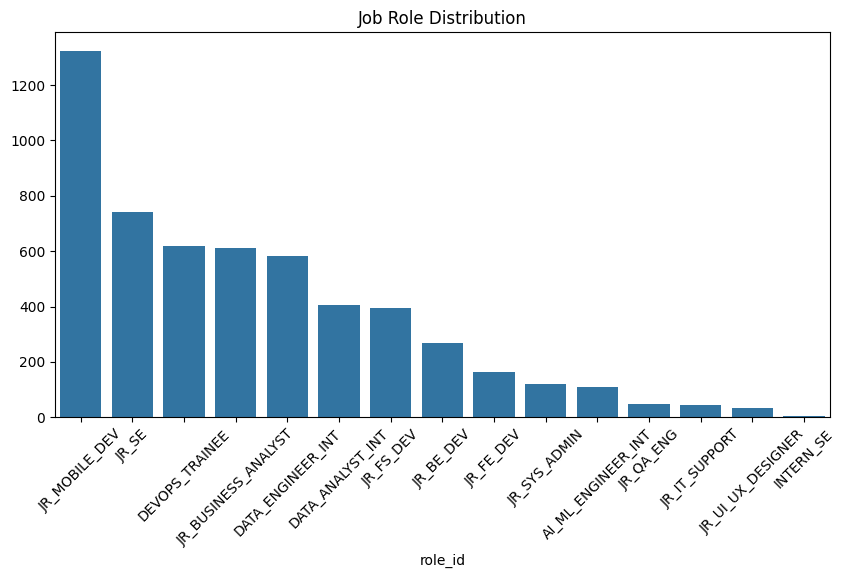

In [6]:
role_counts = df["role_id"].value_counts()

role_counts

plt.figure(figsize=(10,5))
sns.barplot(x=role_counts.index, y=role_counts.values)
plt.xticks(rotation=45)
plt.title("Job Role Distribution")
plt.show()



In [7]:
skill_sums = df[skill_cols].sum()

skill_sums.describe()


,0
count,300.000000
mean,206.130000
std,354.566634
min,0.000000
25%,21.750000
50%,76.500000
75%,207.000000
max,2435.000000


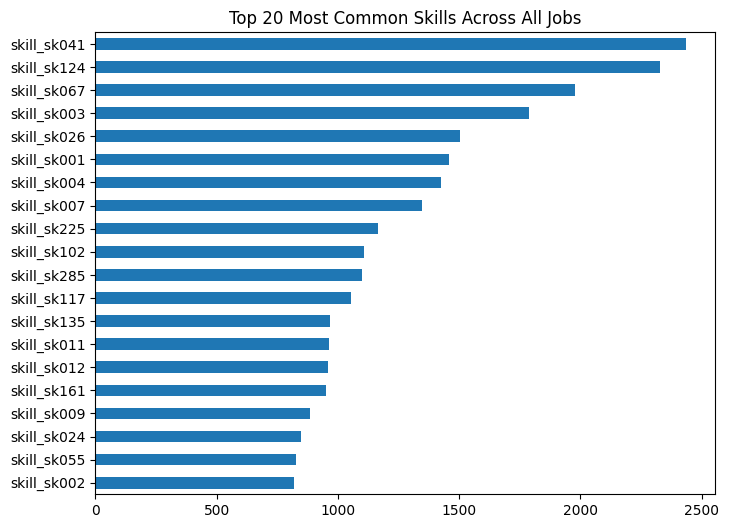

In [8]:
top_skills = skill_sums.sort_values(ascending=False).head(20)

top_skills

plt.figure(figsize=(8,6))
top_skills.plot(kind="barh")
plt.title("Top 20 Most Common Skills Across All Jobs")
plt.gca().invert_yaxis()
plt.show()


In [9]:
def top_skills_for_role(role_id, top_n=10):
    return (
        df[df["role_id"] == role_id][skill_cols]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )
top_skills_for_role("JR_SE")
top_skills_for_role("JR_QA_EN")


,0
skill_sk300,0
skill_sk001,0
skill_sk002,0
skill_sk003,0
skill_sk004,0
skill_sk005,0
skill_sk006,0
skill_sk007,0
skill_sk008,0
skill_sk009,0


In [10]:
df["skill_count"] = df[skill_cols].sum(axis=1)

df["skill_count"].describe()


,skill_count
count,5470.000000
mean,11.305119
std,6.083285
min,0.000000
25%,7.000000
50%,11.000000
75%,15.000000
max,39.000000


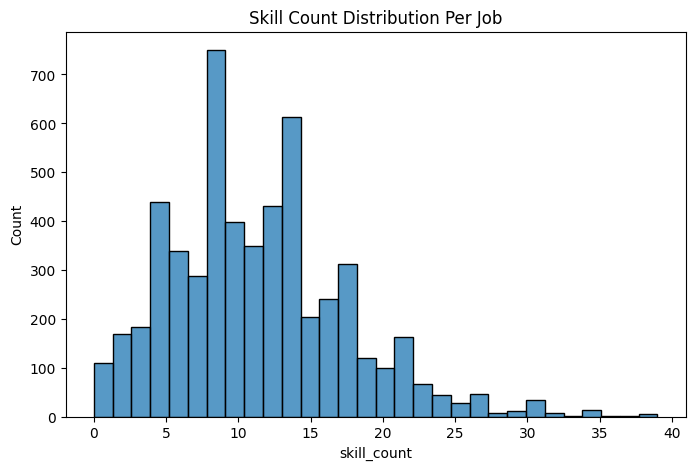

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["skill_count"], bins=30)
plt.title("Skill Count Distribution Per Job")
plt.show()


Key Observations from EDA

The dataset contains X job postings across Y distinct IT roles.

Skill vectors are sparse, with an average of Z skills per job, validating binary encoding.

Certain skills (e.g., SK161, SK102) appear across multiple roles, indicating core IT competencies.

Role-specific skill patterns are evident, supporting skill-based job classification and gap detection.